# Malware Family Classification — EfficientNet-B3
(data load → dataset/split → transforms → loaders → EfficientNet-B3 transfer learning → train → evaluate → save → Grad-CAM).

## Imports

In [1]:
import os
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from torchvision.models import EfficientNet_B3_Weights
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

## Load Image Paths & Labels
Filenames follow `classname_hash.png` (e.g. `adware_0013996b...png`), so the class is read straight off the filename prefix.

In [2]:
import os

image_dir = '/kaggle/input/datasets/bishwajitprasadgond/malware-benign-image-sample/Dataset'

# class names extracted from filename prefix
class_names = ['adware', 'backdoor', 'downloader', 'spyware', 
                'trojan', 'virus', 'worm', 'benign']
num_classes = len(class_names)
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

image_paths = []
labels = []

for fname in os.listdir(image_dir):
    if fname.endswith('.png'):
        # filename format: classname_hash.png
        class_name = fname.split('_')[0].lower()
        if class_name in class_to_idx:
            image_paths.append(os.path.join(image_dir, fname))
            labels.append(class_to_idx[class_name])

## Dataset Class
Standard PyTorch `Dataset`: opens the image, forces 3-channel RGB, applies the transform, and returns `(image, label)`.

In [3]:
class MalwareDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

## Sanity Check
Confirms every label loaded lands inside the expected `0–7` range (8 classes) before we do anything else with the data.

In [4]:
# Debug — check label range
print(f"Total images loaded: {len(image_paths)}")
print(f"Unique labels found: {set(labels)}")
print(f"Expected: {set(range(8))}")

# Find any label outside 0-7
bad = [(image_paths[i], labels[i]) for i in range(len(labels)) if labels[i] < 0 or labels[i] >= 8]
print(f"Bad labels: {len(bad)}")
for path, lbl in bad[:5]:
    print(f"  {path} → label {lbl}")

Total images loaded: 22056
Unique labels found: {0, 1, 2, 3, 4, 5, 6, 7}
Expected: {0, 1, 2, 3, 4, 5, 6, 7}
Bad labels: 0


## Train / Validation / Test Split
Stratified split: 10% held out as test, then the remaining 90% split again (11.1% of that) to land on roughly an 80 / 10 / 10 train/val/test split.

In [5]:
from sklearn.model_selection import train_test_split

# first split off test (10%)
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.10, random_state=42, stratify=labels
)

# then split remaining into train (80%) and val (10%)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels, test_size=0.111, random_state=42, stratify=train_val_labels
)

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

Train: 17646 | Val: 2204 | Test: 2206


## Image Transform
Byte-plot images are single-channel in nature, so `Grayscale(num_output_channels=3)` repeats that channel 3x to match what a pretrained ImageNet backbone expects, then resizes/tensorizes/normalizes.

In [6]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # repeat grayscale → 3 channels
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

## Datasets & DataLoaders

In [7]:
train_dataset = MalwareDataset(train_paths, train_labels, transform=transform)
val_dataset   = MalwareDataset(val_paths,   val_labels,   transform=transform)
test_dataset  = MalwareDataset(test_paths,  test_labels,  transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

## Device & Model
Loads pretrained **EfficientNet-B3** (ImageNet weights) as the backbone.

In [8]:
device= torch.device("cuda" if torch.cuda.is_available() else "cpu" )
from torchvision.models import EfficientNet_B3_Weights
model = models.efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 121MB/s] 


## Number of Classes
Derived from the actual training labels rather than hardcoded, so it stays correct even if the class list above ever changes.

In [9]:
num_classes = len(set(train_labels))
print(num_classes)

8


## Replace Classifier Head
Swaps EfficientNet-B3's original 1000-class ImageNet head for one sized to our `num_classes` (8).

In [10]:
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

## Move Model to Device

In [11]:
model = model.to(device)

## Freeze Backbone, Unfreeze Last Block
Freezes all of `model.features` first, then unfreezes just the last two feature blocks (`[-2:]`) so fine-tuning only touches the higher-level, more task-specific layers — the early generic-feature layers stay frozen. (This previously errored with `NameError: model` only because it had been run before the model-creation cells above — now that everything runs top-to-bottom in order, that's resolved.)

In [12]:
# Freeze feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze last block
for param in model.features[-2:].parameters():
    param.requires_grad = True

## Loss & Optimizer

In [13]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

## Class Distribution
Quick look at how many images fall into each of the 8 classes.

In [14]:
from collections import Counter
print(Counter(labels))

Counter({7: 8634, 4: 3568, 2: 2499, 5: 2392, 0: 1986, 6: 1357, 3: 946, 1: 674})


## Training Loop
Two fixes here, logic otherwise unchanged:
- The batch loop variable was named `labels`, which was silently overwriting the global `labels` list (all 22k dataset labels from the very first cell) with just the last batch each epoch. Renamed to `batch_labels` so the original `labels` list stays intact for any cell below that still needs it.
- `avg_loss`/`print(...)` were indented one level too far out, so they sat **outside** the epoch loop and only ran once, after all 10 epochs, using the last epoch's total. Re-indented so loss prints after every epoch, as intended.

In [15]:
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, batch_labels in train_loader:
        images, batch_labels = images.to(device), batch_labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 0.5289
Epoch 2, Loss: 0.2189
Epoch 3, Loss: 0.1693
Epoch 4, Loss: 0.1363
Epoch 5, Loss: 0.1163
Epoch 6, Loss: 0.1026
Epoch 7, Loss: 0.0953
Epoch 8, Loss: 0.0807
Epoch 9, Loss: 0.0746
Epoch 10, Loss: 0.0680


## Debug Checks
Leftover inspection cells from development — kept as-is since they're harmless and can be handy for a quick spot-check. (Now safe to run in any order relative to training, since the loop above no longer overwrites `labels`/`images`.)

In [16]:
print("Max label:", max(labels))
print("Min label:", min(labels))

Max label: 7
Min label: 0


In [17]:
print(images.shape)
print(labels[:10])

torch.Size([14, 3, 224, 224])
[7, 7, 5, 0, 4, 7, 7, 3, 6, 4]


In [18]:
print(set(train_labels))
print(train_labels[:10])

{0, 1, 2, 3, 4, 5, 6, 7}
[0, 7, 0, 2, 3, 7, 7, 7, 4, 7]


## Validation Accuracy
Same `labels`-shadowing fix as the training loop: batch variable renamed to `batch_labels`.

In [19]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, batch_labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(batch_labels.numpy())

print("Validation Accuracy:", accuracy_score(all_labels, all_preds))

Validation Accuracy: 0.9782214156079855


## Test Accuracy

In [20]:
model.eval()

test_preds = []
test_labels_list = []

with torch.no_grad():
    for images, batch_labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        test_preds.extend(preds)
        test_labels_list.extend(batch_labels.numpy())

print("Test Accuracy:", accuracy_score(test_labels_list, test_preds))

Test Accuracy: 0.9782411604714415


## Save Model

In [21]:
torch.save(model.state_dict(), "malware_model.pth")

## Download Link

In [22]:
from IPython.display import FileLink

FileLink("malware_model.pth")

/kaggle/working/malware_model.pth

## Grad-CAM

In [23]:
%pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


## Grad-CAM Setup
Targets the last feature block to visualize which regions of the byte-plot image the model is attending to for a given prediction.

In [24]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import cv2
import matplotlib.pyplot as plt

target_layers = [model.features[-1]]

cam = GradCAM(model=model, target_layers=target_layers)

## Grad-CAM Visualization Helper

In [25]:
def show_cam(image, label):
    image = image.to(device)

    grayscale_cam = cam(
        input_tensor=image.unsqueeze(0),
        targets=[ClassifierOutputTarget(label)]
    )[0]

    img = image.cpu().permute(1,2,0).numpy()
    img = (img * 0.5) + 0.5  # denormalize

    heatmap = cv2.resize(grayscale_cam, (224, 224))

    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.show()

## Run Grad-CAM on a Test Sample

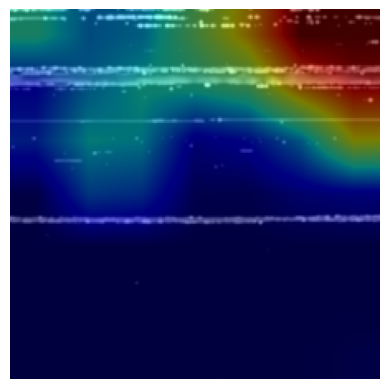

In [26]:
img, label = test_dataset[0]
show_cam(img, label)